In [2]:
import pandas as pd

# Step 1: Load the raw dataset
file_path = '/content/bank-full.csv'  # Replace with your file name
raw_data = pd.read_csv(file_path, header=None)  # Load without assuming headers

# Step 2: Split the data into separate columns using ';' as the delimiter
formatted_data = raw_data[0].str.split(';', expand=True)

# Step 3: Treat the first row as the column headers
formatted_data.columns = formatted_data.iloc[0]  # Set the first row as headers
formatted_data = formatted_data[1:]  # Remove the first row from the data

# Step 4: Remove double quotes from all cells
formatted_data = formatted_data.replace('"', '', regex=True)

# Step 5: Save the cleaned data to a new CSV file
output_file_path = 'formatted_bank_data.csv'
formatted_data.to_csv(output_file_path, index=False)

print(f"Formatted data saved to {output_file_path}")

Formatted data saved to formatted_bank_data.csv


In [3]:
# Load the cleaned data
cleaned_data = pd.read_csv('formatted_bank_data.csv')

# Preview the first few rows
print(cleaned_data.head())


   age         "job" "marital" "education" "default"  "balance" "housing"  \
0   58    management   married    tertiary        no       2143       yes   
1   44    technician    single   secondary        no         29       yes   
2   33  entrepreneur   married   secondary        no          2       yes   
3   47   blue-collar   married     unknown        no       1506       yes   
4   33       unknown    single     unknown        no          1        no   

  "loan" "contact"  "day" "month"  "duration"  "campaign"  "pdays"  \
0     no   unknown      5     may         261           1       -1   
1     no   unknown      5     may         151           1       -1   
2    yes   unknown      5     may          76           1       -1   
3     no   unknown      5     may          92           1       -1   
4     no   unknown      5     may         198           1       -1   

   "previous" "poutcome" "y"  
0           0    unknown  no  
1           0    unknown  no  
2           0    unknow

In [4]:
print(cleaned_data.isnull().sum())


age            0
"job"          0
"marital"      0
"education"    0
"default"      0
"balance"      0
"housing"      0
"loan"         0
"contact"      0
"day"          0
"month"        0
"duration"     0
"campaign"     0
"pdays"        0
"previous"     0
"poutcome"     0
"y"            0
dtype: int64


In [5]:
print(cleaned_data.dtypes)


age             int64
"job"          object
"marital"      object
"education"    object
"default"      object
"balance"       int64
"housing"      object
"loan"         object
"contact"      object
"day"           int64
"month"        object
"duration"      int64
"campaign"      int64
"pdays"         int64
"previous"      int64
"poutcome"     object
"y"            object
dtype: object


In [6]:
print(cleaned_data.describe())


                age      "balance"         "day"    "duration"    "campaign"  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

            "pdays"    "previous"  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       -1.000000      0.

In [7]:
for col in cleaned_data.columns:
    print(f"{col}: {cleaned_data[col].unique()[:5]}")  # Show first 5 unique values


age: [58 44 33 47 35]
"job": ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown']
"marital": ['married' 'single' 'divorced']
"education": ['tertiary' 'secondary' 'unknown' 'primary']
"default": ['no' 'yes']
"balance": [2143   29    2 1506    1]
"housing": ['yes' 'no']
"loan": ['no' 'yes']
"contact": ['unknown' 'cellular' 'telephone']
"day": [5 6 7 8 9]
"month": ['may' 'jun' 'jul' 'aug' 'oct']
"duration": [261 151  76  92 198]
"campaign": [1 2 3 5 4]
"pdays": [ -1 151 166  91  86]
"previous": [0 3 1 4 2]
"poutcome": ['unknown' 'failure' 'other' 'success']
"y": ['no' 'yes']


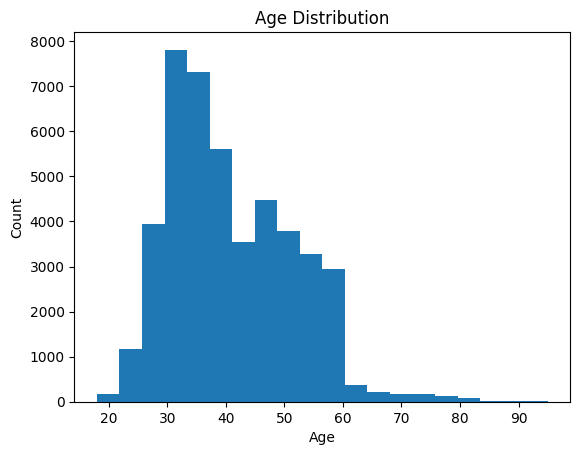

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot a histogram for a numerical column (replace 'age' with your column name)
plt.hist(cleaned_data['age'].astype(float), bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


In [9]:
print(cleaned_data['age'].value_counts())  # Replace 'job' with the relevant column


age
32    2085
31    1996
33    1972
34    1930
35    1894
      ... 
93       2
90       2
95       2
88       2
94       1
Name: count, Length: 77, dtype: int64


Column '"job"' could not be converted to numeric. It is likely categorical.
Column '"marital"' could not be converted to numeric. It is likely categorical.
Column '"education"' could not be converted to numeric. It is likely categorical.
Column '"default"' could not be converted to numeric. It is likely categorical.
Column '"housing"' could not be converted to numeric. It is likely categorical.
Column '"loan"' could not be converted to numeric. It is likely categorical.
Column '"contact"' could not be converted to numeric. It is likely categorical.
Column '"month"' could not be converted to numeric. It is likely categorical.
Column '"poutcome"' could not be converted to numeric. It is likely categorical.
Column '"y"' could not be converted to numeric. It is likely categorical.


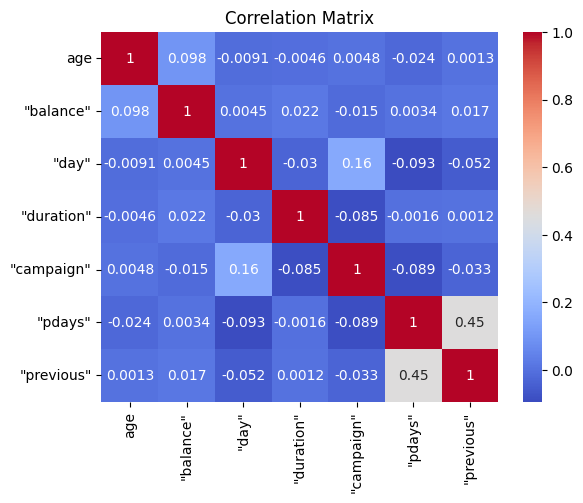

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy library and assign it to the alias 'np'


# Convert relevant columns to numeric, handling errors
for col in cleaned_data.select_dtypes(include=['object']).columns:
    try:
        cleaned_data[col] = pd.to_numeric(cleaned_data[col])
    except ValueError:
        # Handle columns that cannot be converted, like 'job' and others.
        #  We'll keep them as categorical. (You may need to replace with relevant code for one-hot encoding)
        # For instance to apply one-hot encoding:
        #  cleaned_data = pd.get_dummies(cleaned_data, columns=['job'])
        print(f"Column '{col}' could not be converted to numeric. It is likely categorical.")
        pass  # Skip columns that can't be directly converted

# Now, calculate the correlation matrix only on numerical columns
correlation_matrix = cleaned_data.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [11]:
cleaned_data_encoded = pd.get_dummies(cleaned_data, drop_first=True)


In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cleaned_data_scaled = scaler.fit_transform(cleaned_data_encoded)


In [13]:
cleaned_data.to_csv('final_processed_bank_data.csv', index=False)
print("Final processed data saved.")


Final processed data saved.


In [14]:
# Assuming 'cleaned_data' contains the data you want to process
dataset = cleaned_data.copy()  # Create a copy of cleaned_data and assign it to 'dataset'

# Now you can apply get_dummies
dataset = pd.get_dummies(dataset, drop_first=True)

In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(dataset)
dataset = pd.DataFrame(scaled_data, columns=dataset.columns)


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split # Import train_test_split

# Assuming 'dataset' contains your features and 'y_yes' is your target
# Replace 'y_yes' with the actual name of your target column if different after get_dummies
# Check the columns of your dataset after get_dummies
print(dataset.columns) # Print the column names to identify the correct target column name

# Assuming the target column is named 'y_yes' after get_dummies, but replace if necessary
# ----> Changed to search for y_yes and fall back to y_no if not found
target_column = '"y"_yes'  # Modified to match the actual column name
if target_column not in dataset.columns:
    target_column = '"y"_no'  # Modified to match the actual column name
    if target_column not in dataset.columns:
        raise KeyError(f"Neither '\"y\"_yes' nor '\"y\"_no' found in the dataset columns: {dataset.columns}")


X = dataset.drop(columns=[target_column], errors='ignore') # ignore the error just in case the column has a different name or does not exist
y = dataset[target_column]  # Adjust this line to match the actual name of your target column

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Split data

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train) # Fit the model

Index(['age', '"balance"', '"day"', '"duration"', '"campaign"', '"pdays"',
       '"previous"', '"job"_blue-collar', '"job"_entrepreneur',
       '"job"_housemaid', '"job"_management', '"job"_retired',
       '"job"_self-employed', '"job"_services', '"job"_student',
       '"job"_technician', '"job"_unemployed', '"job"_unknown',
       '"marital"_married', '"marital"_single', '"education"_secondary',
       '"education"_tertiary', '"education"_unknown', '"default"_yes',
       '"housing"_yes', '"loan"_yes', '"contact"_telephone',
       '"contact"_unknown', '"month"_aug', '"month"_dec', '"month"_feb',
       '"month"_jan', '"month"_jul', '"month"_jun', '"month"_mar',
       '"month"_may', '"month"_nov', '"month"_oct', '"month"_sep',
       '"poutcome"_other', '"poutcome"_success', '"poutcome"_unknown',
       '"y"_yes'],
      dtype='object')


RandomForestClassifier(random_state=42)

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the formatted dataset
data = pd.read_csv('formatted_bank_data.csv')

# Separate features and target
X = data.drop('"y"', axis=1)  # Replace 'target_column' with the actual target column name '"y"'
y = data['"y"']  # Replace 'target_column' with the actual target column name '"y"'

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data loaded and split into training and testing sets.")

Data loaded and split into training and testing sets.


In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Load the formatted dataset
data = pd.read_csv('formatted_bank_data.csv')

# Separate features and target
X = data.drop('"y"', axis=1)  # Replace 'target_column' with the actual target column name '"y"'
y = data['"y"']  # Replace 'target_column' with the actual target column name '"y"'

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()


# Create a preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),  # Numerical features are passed through
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features),  # Categorical features are one-hot encoded
    ])


# Create a pipeline with the preprocessor and the RandomForestClassifier
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42)),
])

# Train the pipeline
pipeline.fit(X_train, y_train)

# Predict on the test set
pipeline_predictions = pipeline.predict(X_test)
pipeline_probabilities = pipeline.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Classification Report (with Pipeline):")
print(classification_report(y_test, pipeline_predictions))
print("AUC-ROC Score (with Pipeline):", roc_auc_score(y_test, pipeline_probabilities))

Random Forest Classification Report (with Pipeline):
              precision    recall  f1-score   support

          no       0.92      0.97      0.95      7952
         yes       0.67      0.41      0.51      1091

    accuracy                           0.91      9043
   macro avg       0.80      0.69      0.73      9043
weighted avg       0.89      0.91      0.89      9043

AUC-ROC Score (with Pipeline): 0.9271856505670134
